# *ASSIGNMENT-3: Sending messages through a network*

In [96]:
import networkx as nx
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
from itertools import combinations
from collections import Counter

In [97]:
MESSAGE_TRUE = "Real"
MESSAGE_MUTATED = "Altered"
MESSAGE_FAKE = "Fake"
MESSAGE_NONE = None
random.seed(42)

In [98]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [99]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [100]:
G = build_graph(df)

## Verifiers and Unintentional nodes

In [101]:
def assign_roles(G, n_verifiers=5, n_unintentional=5, unint_strategy="random", betweenness=None):
    nodes = list(G.nodes())
    roles = {node: "normal" for node in nodes}
    # Verifiers casuali
    verifiers = random.sample(nodes, n_verifiers)
    for v in verifiers:
        roles[v] = "verifier"
    remaining = [n for n in nodes if n not in verifiers]
    # Scelta degli Unintentional
    if unint_strategy == "random":
        unint = random.sample(remaining, n_unintentional)
    elif unint_strategy == "degree":
        ranked = sorted(remaining, key=lambda n: G.degree[n], reverse=True)
        unint = ranked[:n_unintentional]
    elif unint_strategy == "betweenness":
        if betweenness is None:
            raise ValueError("Passare la betweenness già calcolata.")
        ranked = sorted(remaining, key=lambda n: betweenness[n], reverse=True)
        unint = ranked[:n_unintentional]
    else:
        raise ValueError("Strategia non valida.")
    for u in unint:
        roles[u] = "unintentional"
    return roles

In [102]:
def adopt_message(node, neighbors_dict, messages, threshold):
    neighbors = neighbors_dict[node]
    if not neighbors:
        return MESSAGE_NONE
    counts = {}
    for n in neighbors:
        msg = messages[n]
        if msg is not None:
            counts[msg] = counts.get(msg, 0) + 1
    if not counts:
        return MESSAGE_NONE
    majority_msg = max(counts, key=counts.get)
    frac = counts[majority_msg] / len(neighbors)
    if frac >= threshold:
        return majority_msg
    return MESSAGE_NONE

In [103]:
def prepare_neighbors(G):
    return {node: list(G.neighbors(node)) for node in G.nodes()}

In [104]:
def simulate_spread(G, roles, threshold=0.3, max_steps=20, neighbors_dict=None):
    if neighbors_dict is None:
        neighbors_dict = prepare_neighbors(G)
    messages = {
        node: MESSAGE_NONE
        for node in G.nodes()
    }
    for node, role in roles.items():
        if role == "verifier":
            messages[node] = MESSAGE_TRUE
    for step in range(max_steps):
        new_messages = messages.copy()
        changed = False
        for node in G.nodes():
            role = roles[node]
            if role == "verifier":
                continue
            if role == "unintentional":
                if messages[node] is None:
                    adopted = adopt_message(node, neighbors_dict, messages, threshold)
                    if adopted == MESSAGE_TRUE:
                        new_messages[node] = MESSAGE_MUTATED
                        changed = True
                continue
            if role == "normal":
                adopted = adopt_message(node, neighbors_dict, messages, threshold)
                if adopted != messages[node]:
                    new_messages[node] = adopted
                    changed = True
        messages = new_messages
        if not changed:
            break
    return messages

In [105]:
def analyze(messages):
    total = len(messages)
    counter = Counter(messages.values())
    return {
        "true": counter[MESSAGE_TRUE] / total,
        "mutated": counter[MESSAGE_MUTATED] / total,
        "fake": counter[MESSAGE_FAKE] / total,
        "none": counter[None] / total
    }

## Adding Social Bots

In [106]:
def assign_bots(G, roles, n_bots=3, mode="degree"):
    roles = roles.copy()
    available = [
        n for n, r in roles.items()
        if r == "normal"
    ]
    if mode == "degree":
        centrality = dict(G.degree())
    elif mode == "betweenness":
        centrality = nx.betweenness_centrality(G)
    else:
        raise ValueError("Mode deve essere 'degree' o 'betweenness'.")
    ranked = sorted(available, key=lambda n: centrality[n], reverse=True)
    bots = ranked[:n_bots]
    for b in bots:
        roles[b] = "bot"
    return roles

In [107]:
def simulate_spread_with_bots(G, roles, threshold=0.3, max_steps=20):
    messages = {node: MESSAGE_NONE for node in G.nodes()}
    for node, role in roles.items():
        if role == "verifier":
            messages[node] = MESSAGE_TRUE
    for step in range(max_steps):
        new_messages = messages.copy()
        for node in G.nodes():
            role = roles[node]
            if role == "verifier":
                continue
            if role == "bot":
                neighbors = list(G.neighbors(node))
                if any(messages[n] is not None for n in neighbors):
                    new_messages[node] = MESSAGE_FAKE
                continue
            if role == "unintentional":
                if messages[node] is None:
                    adopted = adopt_message(node, G, messages, threshold)
                    if adopted == MESSAGE_TRUE:
                        new_messages[node] = MESSAGE_MUTATED
                continue
            if role == "normal":
                if any(messages[n] == MESSAGE_FAKE for n in G.neighbors(node)):
                    new_messages[node] = MESSAGE_FAKE
                    continue
                adopted = adopt_message(node, G, messages, threshold)
                new_messages[node] = adopted
        if new_messages == messages:
            break
        messages = new_messages
    return messages

In [108]:
def experiment_unintentional(G, threshold=0.05, max_unintentional=40, runs=10, unint_strategy="random"):
    results = []
    # Calcola UNA SOLA VOLTA la betweenness
    betweenness = None
    if unint_strategy == "betweenness":
        print("Computing betweenness...")
        betweenness = nx.betweenness_centrality(G, k=200, seed=42)
        print("Betweenness completed.")
    for u in range(max_unintentional + 1):
        mutated_list = []
        for _ in range(runs):
            roles = assign_roles(G, n_verifiers=50, n_unintentional=u, unint_strategy=unint_strategy, betweenness=betweenness)
            messages = simulate_spread(G, roles, threshold)
            mutated = (sum(1 for m in messages.values() if m == MESSAGE_MUTATED)/ G.number_of_nodes())
            mutated_list.append(mutated)
        avg_mutated = sum(mutated_list) / runs
        results.append((u, avg_mutated))
    return results

In [109]:
def plot_phase_transition(results_random, results_degree):
    plt.figure(figsize=(8, 6))
    plt.plot(
        [x for x, _ in results_random],
        [y for _, y in results_random],
        marker="o",
        label="Random"
    )

    plt.plot(
        [x for x, _ in results_degree],
        [y for _, y in results_degree],
        marker="s",
        label="Betweenness"
    )

    plt.xlabel("Number of Unintentional nodes")
    plt.ylabel("Fraction of mutated messages")
    plt.title("Random vs strategic placement of Unintentional nodes")
    plt.grid(True)
    plt.legend()
    plt.show()

In [110]:
def print_phase_transition_results(results):
    print("=== RISULTATI FASE DI TRANSIZIONE ===\n")
    print(f"{'u (Unintentional)':>20} | {'% MUTATED':>10}")
    print("-" * 35)
    for u, mutated in results:
        print(f"{u:>20} | {mutated:>10.4f}")

In [111]:
def plot_comparison(G, messages_part1, roles_part1, messages_part2, roles_part2):
    # Giant component per stabilità visiva
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    pos = nx.spring_layout(G, seed=42, k=0.15, iterations=50)

    def get_colors_and_sizes(messages, roles):
        colors = []
        sizes = []
        for n in G.nodes():
            role = roles[n]
            msg = messages[n]

            if role == "verifier":
                colors.append("green")
                sizes.append(180)
            elif role == "unintentional":
                colors.append("yellow")
                sizes.append(150)
            elif role == "bot":
                colors.append("red")
                sizes.append(200)
            else:
                if msg == MESSAGE_TRUE:
                    colors.append("blue")
                elif msg == MESSAGE_MUTATED:
                    colors.append("orange")
                elif msg == MESSAGE_FAKE:
                    colors.append("purple")
                else:
                    colors.append("gray")
                sizes.append(80)
        return colors, sizes

    colors1, sizes1 = get_colors_and_sizes(messages_part1, roles_part1)
    colors2, sizes2 = get_colors_and_sizes(messages_part2, roles_part2)

    plt.figure(figsize=(18, 8))

    # Parte 1
    plt.subplot(1, 2, 1)
    nx.draw(G, pos, node_color=colors1, node_size=sizes1, edge_color="lightgray", alpha=0.85)
    plt.title("Parte 1 — Diffusione senza Bots", fontsize=16)

    # Parte 2
    plt.subplot(1, 2, 2)
    nx.draw(G, pos, node_color=colors2, node_size=sizes2, edge_color="lightgray", alpha=0.85)
    plt.title("Parte 2 — Diffusione con Bots", fontsize=16)
    plt.show()

In [112]:
print("Start assign roles")
roles = assign_roles(G, n_verifiers=200, n_unintentional=10)

print("Start simulate spread")
messages = simulate_spread(G, roles, threshold=0.01)
print(analyze(messages))

Start assign roles
Start simulate spread
{'true': 0.8052528639284716, 'mutated': 0.0022352612461581448, 'fake': 0.0, 'none': 0.19251187482537022}


In [113]:
print("Start assign bots")
roles_bots = assign_bots(G, roles, n_bots=3, mode="betweenness")

print("Start simulate spread with bots")
messages_bots = simulate_spread_with_bots(G, roles_bots, threshold=0.3)
print(analyze(messages_bots))

Start assign bots
Start simulate spread with bots
{'true': 0.056160938809723386, 'mutated': 0.0, 'fake': 0.7474154791841296, 'none': 0.19642358200614696}


In [114]:
print("Start experiment unintentional random")
results_random = experiment_unintentional(G, threshold=0.05, max_unintentional=40, unint_strategy="random")
print_phase_transition_results(results_random)

Start experiment unintentional random
=== RISULTATI FASE DI TRANSIZIONE ===

   u (Unintentional) |  % MUTATED
-----------------------------------
                   0 |     0.0000
                   1 |     0.0002
                   2 |     0.0003
                   3 |     0.0004
                   4 |     0.0007
                   5 |     0.0006
                   6 |     0.0012
                   7 |     0.0009
                   8 |     0.0008
                   9 |     0.0013
                  10 |     0.0012
                  11 |     0.0013
                  12 |     0.0020
                  13 |     0.0021
                  14 |     0.0029
                  15 |     0.0026
                  16 |     0.0034
                  17 |     0.0035
                  18 |     0.0026
                  19 |     0.0036
                  20 |     0.0036
                  21 |     0.0044
                  22 |     0.0039
                  23 |     0.0043
                  24 |     0.0056
   

In [115]:
print("Start experiment unintentional betweenness")
results_betweenness = experiment_unintentional(G, threshold=0.05, max_unintentional=40, unint_strategy="betweenness")
print_phase_transition_results(results_betweenness)

Start experiment unintentional betweenness
Computing betweenness...
Betweenness completed.
=== RISULTATI FASE DI TRANSIZIONE ===

   u (Unintentional) |  % MUTATED
-----------------------------------
                   0 |     0.0000
                   1 |     0.0003
                   2 |     0.0004
                   3 |     0.0007
                   4 |     0.0010
                   5 |     0.0014
                   6 |     0.0013
                   7 |     0.0020
                   8 |     0.0031
                   9 |     0.0036
                  10 |     0.0030
                  11 |     0.0028
                  12 |     0.0037
                  13 |     0.0026
                  14 |     0.0027
                  15 |     0.0037
                  16 |     0.0051
                  17 |     0.0033
                  18 |     0.0044
                  19 |     0.0039
                  20 |     0.0061
                  21 |     0.0058
                  22 |     0.0068
                  

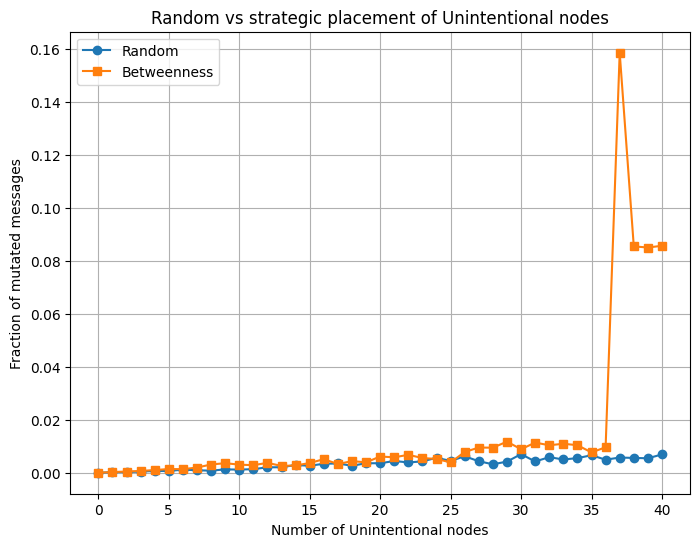

In [116]:
plot_phase_transition(results_random, results_betweenness)

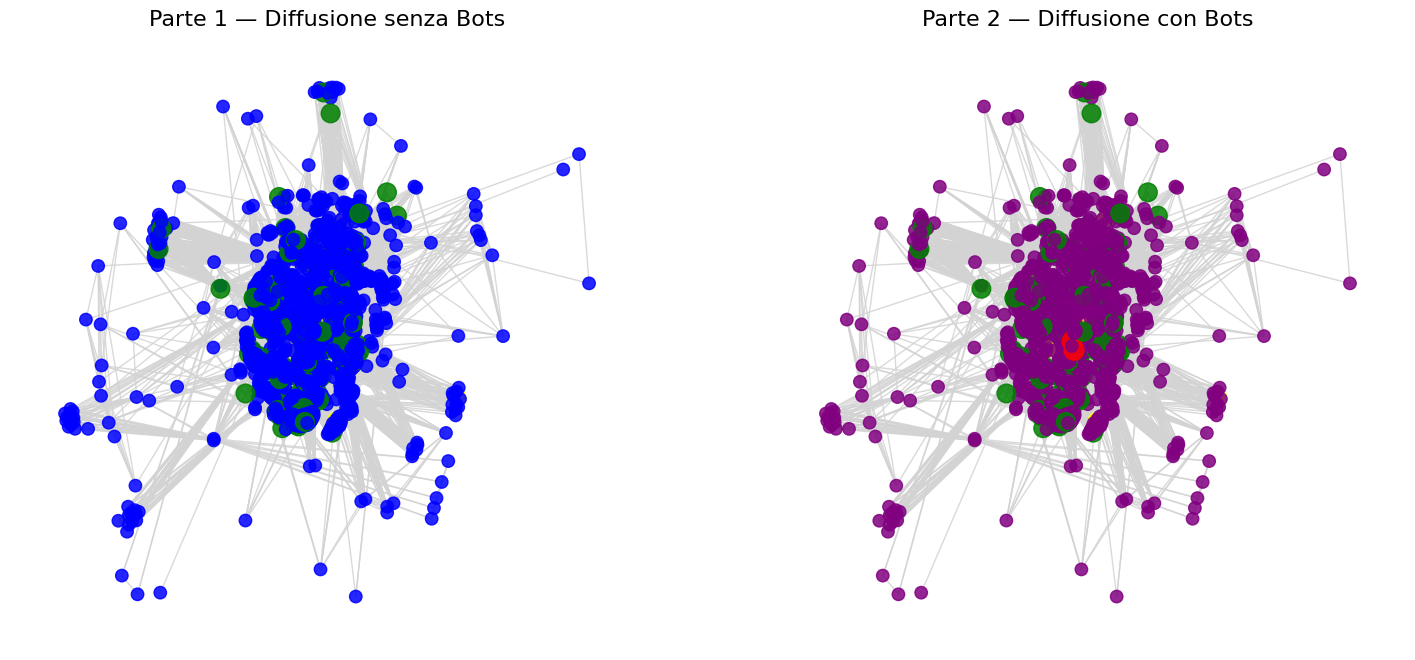

In [117]:
plot_comparison(G, messages, roles, messages_bots, roles_bots)

In [118]:
print(Counter(messages.values()))
print(Counter(messages_bots.values()))

Counter({'Real': 2882, None: 689, 'Altered': 8})
Counter({'Fake': 2675, None: 703, 'Real': 201})
